In [82]:
import numpy as np
import pandas as pd

In [83]:
df = pd.read_csv(r"C:\ProgFiles\IIT-PATNA\Dataset\used_cars_messy.csv")
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0


Task 1 — Explore and Identify Issues Load the dataset and use df.info(), df.describe(), and df.shape to report at least three data quality problems you observe (e.g., wrong dtypes, nulls, impossible values).

In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  str    
 2   brand              15661 non-null  str    
 3   model              15661 non-null  str    
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  str    
 6   seller_type        15661 non-null  str    
 7   fuel_type          15661 non-null  str    
 8   transmission_type  15661 non-null  str    
 9   mileage            14376 non-null  str    
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), str(8)
memory usage: 1.7 MB


In [85]:
df.describe()

,Unnamed: 0,vehicle_age,engine,max_power,seats,selling_price
count,15661.000000,15661.000000,13792.000000,14862.000000,15218.000000,1.550300e+04
mean,9808.189643,6.036843,1480.489342,100.513582,5.324418,1.032764e+06
std,5642.981540,3.015072,511.446057,42.854632,0.805993,1.607380e+07
min,0.000000,0.000000,793.000000,38.400000,0.000000,5.000000e+02
25%,4901.000000,4.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9858.000000,6.000000,1248.000000,88.500000,5.000000,5.550000e+05
75%,14666.000000,8.000000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,6592.000000,626.000000,9.000000,1.000000e+09


In [86]:
df.shape

(15661, 14)

The main quality issues that I have identified are:
1. km_driven and mileage columns are in string data type. They need to be converted to an integer data type
2.  mileage engine,       
    max_power,          
    seats,    columns contain very huge number of null values that has to be imputed
3. selling_price also has null values. But it's not recommended to impute the values of the target column. Mostly it's preferred to drop the records where the target column has null values
4. Remove a useless column named "Unnamed: 0"
5. An impossible value in the seats feature is '0'. No car has 0 seats.
6. Selling price also some outliers that are very far away from the actual mean of the data.

Task 2 — Clean the Data Fix the issues identified: drop null target rows, impute missing input features, strip and lowercase the brand column, extract numeric values from the mileage column, and remove duplicates.

In [87]:
missing = pd.DataFrame({
    "Missing count" : df.isnull().sum(),
    "Missing percentage" : df.isnull().sum() * 100 / len(df)
})
missing = missing[missing['Missing count'] > 0]
missing

,Missing count,Missing percentage
mileage,1285,8.205095
engine,1869,11.934104
max_power,799,5.101845
seats,443,2.828683
selling_price,158,1.008876


In [88]:
print("Exact duplicated rows are: ", df.duplicated().sum())
print("Duplicated rows: ")
duplicates = df[df.duplicated(keep=False)].sort_values('car_name')
duplicates.head()

Exact duplicated rows are:  169
Duplicated rows: 


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
9347,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
5920,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
13398,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
3642,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
867,16053,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993.0,NaN,4.0,5600000.0


In [89]:
# Check unique values in categorical columns
cat_cols = ['brand', 'seller_type', 'fuel_type', 'transmission_type']

for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"\nNumber of unique values in the {col.upper()} column are: {len(unique_vals)}")
    print("Unique values are: ", unique_vals)


Number of unique values in the BRAND column are: 80
Unique values are:  <StringArray>
[        'Renault',          'Maruti',           'Honda',        'Mahindra',
         'Hyundai',            'Ford',            'Jeep',             'BMW',
          'Jaguar',           'Skoda',      'Volkswagen',            'Tata',
   'Mercedes-Benz',          'Datsun',            'Audi',           'Tata ',
           'Lexus',        'Hyundai ',          'Toyota',         'Maruti ',
       'Mahindra ',        ' Maruti ',            'BMW ',          'Nissan',
       ' Mahindra',      ' Mahindra ',          ' Honda',        ' Hyundai',
         ' Maruti',      'Land Rover', ' Mercedes-Benz ',            'Mini',
         ' Honda ',          ' Ford ',           'Volvo',         ' Toyota',
         'Porsche',          ' Tata ',    ' Volkswagen ',       ' Hyundai ',
             'Kia',              'MG',            ' BMW',           'Isuzu',
           ' Ford',           'Ford ',       ' Renault ',         

In [90]:
df.dropna(subset=['selling_price'], inplace=True)

In [91]:
df.drop("Unnamed: 0", axis=1, inplace=True)
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0


In [92]:
print("Number of unique car brands before cleaning: ", len(df['brand'].unique()))

df['brand'] = df['brand'].astype('str').str.strip().str.title()
print("After cleaning and removing duplicates: ", len(df['brand'].unique()))

df['brand'].value_counts().head(10)

Number of unique car brands before cleaning:  80
After cleaning and removing duplicates:  31


brand
Maruti        5020
Hyundai       3002
Honda         1495
Mahindra      1015
Toyota         801
Ford           792
Volkswagen     627
Renault        539
Bmw            440
Tata           433
Name: count, dtype: int64

In [93]:
print("Before removing duplicates: ", len(df['seller_type'].unique()))

typo_map = {
    'Individuall': 'Individual',
    'Delaer': 'Dealer',
    'Individul': 'Individual'
}
df['seller_type'] = df['seller_type'].astype('str').str.strip().str.title().replace(typo_map)

print("After removing duplicates: ", len(df['seller_type'].unique()))
df['seller_type'].value_counts().head(6)

Before removing duplicates:  9
After removing duplicates:  3


seller_type
Dealer              9592
Individual          5738
Trustmark Dealer     173
Name: count, dtype: int64

In [94]:
print("Before removing duplicates: ", len(df['fuel_type'].unique()))

df['fuel_type'] = df['fuel_type'].str.strip().str.title()

print("After removing duplicates ", len(df['fuel_type'].unique()))

Before removing duplicates:  14
After removing duplicates  5


In [95]:
df['transmission_type'].unique()

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

## Numerical columns

In [96]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,Cng,Manual,33.54,998.0,67.04,5.0,435000.0
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,Dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0


In [98]:
df = df[df['selling_price'] != 999999999.0]

In [99]:
num_cols = ['km_driven', 'mileage', 'engine', 'max_power', 'seats']

df['selling_price'].isnull().sum()

np.int64(0)

In [100]:
df.info()

<class 'pandas.DataFrame'>
Index: 15499 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15499 non-null  str    
 1   brand              15499 non-null  str    
 2   model              15499 non-null  str    
 3   vehicle_age        15499 non-null  int64  
 4   km_driven          15499 non-null  str    
 5   seller_type        15499 non-null  str    
 6   fuel_type          15499 non-null  str    
 7   transmission_type  15499 non-null  str    
 8   mileage            14230 non-null  str    
 9   engine             13647 non-null  float64
 10  max_power          14709 non-null  float64
 11  seats              15061 non-null  float64
 12  selling_price      15499 non-null  float64
dtypes: float64(4), int64(1), str(8)
memory usage: 1.7 MB


## Data Types conversion

In [101]:
to_convert = ['km_driven', 'mileage']

In [102]:
df['km_driven'] = df['km_driven'].astype(str).str.strip().str.replace(",", "").str.replace("s", "").str.replace("km", "")

df['km_driven'] = pd.to_numeric(df['km_driven'])

In [103]:
df['mileage'] = df['mileage'].astype('str').str.strip().str.replace('kmpl', "").str.replace("km", "")

df['mileage'] = pd.to_numeric(df['mileage'])


In [104]:
df.info()

<class 'pandas.DataFrame'>
Index: 15499 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15499 non-null  str    
 1   brand              15499 non-null  str    
 2   model              15499 non-null  str    
 3   vehicle_age        15499 non-null  int64  
 4   km_driven          15499 non-null  int64  
 5   seller_type        15499 non-null  str    
 6   fuel_type          15499 non-null  str    
 7   transmission_type  15499 non-null  str    
 8   mileage            14230 non-null  float64
 9   engine             13647 non-null  float64
 10  max_power          14709 non-null  float64
 11  seats              15061 non-null  float64
 12  selling_price      15499 non-null  float64
dtypes: float64(5), int64(2), str(6)
memory usage: 1.7 MB


### Handling missing values in independent columns

In [105]:
missing_vals = ['mileage', 'engine', 'max_power', 'seats']

In [106]:
df['mileage'] = df.groupby('fuel_type')['mileage'].transform(
    lambda x: x.fillna(x.median())
)

In [107]:
!pip install seaborn
!pip install matplotlib

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

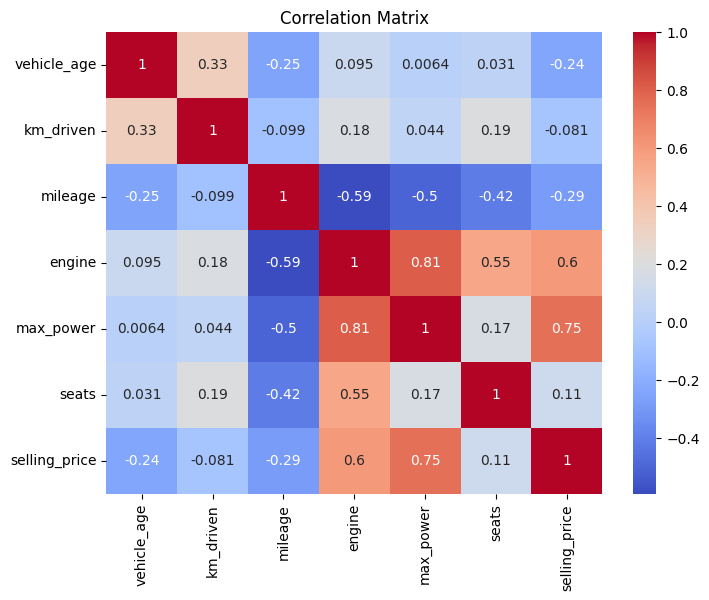

In [109]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [110]:
df['mileage'] = df.groupby(['fuel_type'])['mileage'].transform(
    lambda x: x.fillna(x.median())
)

In [111]:
df['engine'] = df.groupby('brand')['engine'].transform(
    lambda x : x.fillna(x.median())
)

In [112]:
df['max_power'] = df.groupby('engine')['max_power'].transform(
    lambda x : x.fillna(x.median())
)

In [113]:
df['seats'] = df['seats'].fillna(df['seats'].mode()[0])

In [114]:
df.info()

<class 'pandas.DataFrame'>
Index: 15499 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15499 non-null  str    
 1   brand              15499 non-null  str    
 2   model              15499 non-null  str    
 3   vehicle_age        15499 non-null  int64  
 4   km_driven          15499 non-null  int64  
 5   seller_type        15499 non-null  str    
 6   fuel_type          15499 non-null  str    
 7   transmission_type  15499 non-null  str    
 8   mileage            15499 non-null  float64
 9   engine             15499 non-null  float64
 10  max_power          15499 non-null  float64
 11  seats              15499 non-null  float64
 12  selling_price      15499 non-null  float64
dtypes: float64(5), int64(2), str(6)
memory usage: 1.7 MB


Task 3 — Compute Baseline MAE Build a baseline model that predicts the mean selling_price for every record. Calculate and print the MAE of this baseline on the full cleaned dataset.

In [115]:
from sklearn.model_selection import train_test_split

x = df.drop('selling_price', axis=1)
y = df['selling_price']

In [116]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=43
)

In [117]:
baseline_pred = [y_train.mean()] * len(y_test)

In [118]:
from sklearn.metrics import mean_absolute_error
mae_baseline = mean_absolute_error(y_test, baseline_pred)
print("Baseline MAE: ", mae_baseline)

Baseline MAE:  456509.4078736839
